# Paraglideml — inference demo

This notebook drives the **torch-free inference library**: load the bundled model, score a
day's paragliding XC potential over every Alpine cell, turn it into the GeoJSON the map
consumes, and plot it.

The model (`exp_056`, calibrated `HistGradientBoosting`) ships **inside the package**, so a
fresh install predicts out of the box — no PyTorch, no separate weights download.

## Install

```bash
pip install 'paraglideml[inference] @ git+https://github.com/Genajoin/paraglideml.git@v0.1.0'
```

(or `pip install -e .` from a checkout). The `[inference]` core is lean; the heavy training
stack lives behind the `[train]` extra and is not needed here.

In [1]:
from paraglideml import predict_tiers, tiers_to_geojson, TIERS

# Cumulative distance tiers — each implies the ones below it.
TIERS  # [(15.0, 'flyable'), (50.0, 'good'), (100.0, 'epic')]

[(15.0, 'flyable'), (50.0, 'good'), (100.0, 'epic')]

## Score a day

`predict_tiers(date)` downloads the GFS slice for the date, builds the features for every
selected 1° cell, runs the three calibrated tier models, and returns one row per cell with
the cumulative, calibrated probabilities `P(≥flyable) ≥ P(≥good) ≥ P(≥epic)`.

> Pass a recent date for which GFS analysis exists. For a forecast off an earlier cycle, use
> `predict_tiers(date, run_date=...)` or the `forecast_window(run_date, days=3)` helper.

In [2]:
import pandas as pd

DATE = "2026-06-12"  # a recent date with GFS analysis available
rows = predict_tiers(DATE)

df = pd.DataFrame(rows).sort_values("p_good", ascending=False).reset_index(drop=True)
print(f"{len(df)} cells scored for {DATE}")
df.head(10)

>>> Fetching GFS for 2026-06-12 (analysis) ...
  slices: {6: 'cached', 12: 'cached', 18: 'cached'}
>>> Extracting features to cache ...
Processing GFS cache for 3 timestamps and 66 cells.


Processing GRIBs:   0%|          | 0/3 [00:00<?, ?it/s]

Processing GRIBs:  33%|███▎      | 1/3 [00:01<00:02,  1.03s/it]

Processing GRIBs:  67%|██████▋   | 2/3 [00:01<00:00,  1.03it/s]

Processing GRIBs: 100%|██████████| 3/3 [00:02<00:00,  1.05it/s]

Processing GRIBs: 100%|██████████| 3/3 [00:02<00:00,  1.04it/s]


Summary: Processed=3, Skipped=0, Missing=0, Errors=0


45 cells scored for 2026-06-12


,cell,lat,lon,date,lead,p_flyable,p_good,p_epic
0,45_6,45,6,2026-06-12,0,0.973856,0.826087,0.565217
1,45_11,45,11,2026-06-12,0,0.973856,0.763636,0.030172
2,46_6,46,6,2026-06-12,0,1.000000,0.763636,0.065217
3,44_10,44,10,2026-06-12,0,0.973856,0.763636,0.258065
4,46_13,46,13,2026-06-12,0,1.000000,0.562500,0.325000
5,46_14,46,14,2026-06-12,0,0.907801,0.562500,0.030172
6,45_10,45,10,2026-06-12,0,0.973856,0.534483,0.030172
7,45_7,45,7,2026-06-12,0,0.973856,0.534483,0.258065
8,46_7,46,7,2026-06-12,0,0.907801,0.534483,0.005917
9,44_7,44,7,2026-06-12,0,0.916667,0.534483,0.258065


## The map artifact

`tiers_to_geojson` renders the rows as a FeatureCollection of **honest 1° squares** (the model
granularity is ~100 km — never point accuracy). This is the exact contract the Cloudflare
Worker serves and the MapLibre layer reads.

In [3]:
gj = tiers_to_geojson(rows, DATE)
print(gj["type"], "·", len(gj["features"]), "features")
gj["features"][0]

FeatureCollection · 45 features


{'type': 'Feature',
 'geometry': {'type': 'Polygon',
  'coordinates': [[[6, 45], [7, 45], [7, 46], [6, 46], [6, 45]]]},
 'properties': {'cell': '45_6',
  'p_flyable': 0.9739,
  'p_good': 0.8261,
  'p_epic': 0.5652,
  'date': '2026-06-12',
  'lead': 0}}

## Map the cells

Colour each cell by `P(≥good)` (XC ≥ 50 km) with the same cool→warm ramp the production map
uses: pale = unlikely, green = a good XC day, orange = a standout.

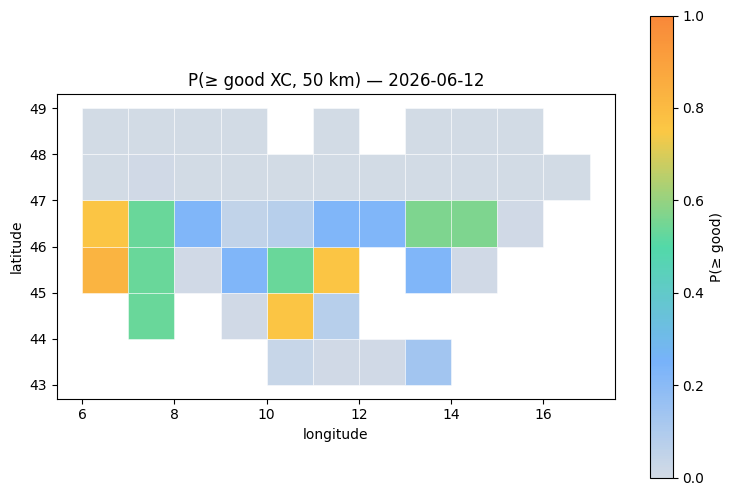

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib.colors import LinearSegmentedColormap, Normalize

cmap = LinearSegmentedColormap.from_list(
    "flyability", ["#cbd5e1", "#60a5fa", "#34d399", "#fbbf24", "#f97316"]
)
norm = Normalize(0.0, 1.0)

fig, ax = plt.subplots(figsize=(9, 6))
squares = [Rectangle((r["lon"], r["lat"]), 1, 1) for r in rows]
pc = PatchCollection(squares, cmap=cmap, norm=norm, edgecolor="white", linewidth=0.4, alpha=0.85)
pc.set_array(np.array([r["p_good"] for r in rows]))
ax.add_collection(pc)
ax.autoscale_view()
ax.set_aspect("equal")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title(f"P(≥ good XC, 50 km) — {DATE}")
fig.colorbar(pc, ax=ax, label="P(≥ good)")
plt.show()

## Tier table for the best cell

The per-cell breakdown — the same table the Telegram bot and the map popup show.

In [5]:
best = df.iloc[0]
print(f"Cell {best['cell']}  ({best['lat']:.0f}°N {best['lon']:.0f}°E)  —  {DATE}\n")
for km, label in TIERS:
    print(f"  P(≥ {label:<7} {km:>5.0f} km) = {best['p_' + label]:.0%}")

Cell 45_6  (45°N 6°E)  —  2026-06-12

  P(≥ flyable    15 km) = 97%
  P(≥ good       50 km) = 83%
  P(≥ epic      100 km) = 57%


## Pointing at a fresher model

Inference defaults to the **bundled** model. A production deployment can point at a newer
model on disk (retrained on a cadence, synced from object storage) **without re-releasing the
library** — set the env override before importing/scoring:

```bash
export PARAGLIDEML_MODEL_DIR=/srv/models/exp_latest
```

`model_dir()` in `paraglideml.assets` resolves `$PARAGLIDEML_MODEL_DIR` first, else the
bundled default — so code cadence (rare) is decoupled from model cadence (every retrain).